# Cohort Analytics

Three predefined phenotypes (`src/analytics/predefined_cohorts.py`), each
exercising a different shape of temporal logic in `CohortBuilder`
(`src/analytics/cohort_builder.py`):

- **diabetes_complications** — an index condition followed by an outcome
  condition within a window (`execute()`, generalized to work across any pair
  of clinical domains, not just drug-then-condition)
- **opioid_escalation** — a sequence of prescriptions climbing a potency
  ladder within a window (`execute_escalation()`)
- **polypharmacy_elderly** — peak concurrently-active drug count, independent
  of any single reference date (`execute_concurrent_drug_count()`, a
  sweep-line over each patient's own exposure intervals)

This notebook runs all three and visualizes both how each population narrows
(attrition) and, for the escalation cohort specifically, what the underlying
prescription pattern actually looks like.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "..")
sys.path.insert(0, ".")
from src.config.settings import settings

# Jupyter's kernel CWD is this notebook's own folder, but settings.duckdb_path
# defaults to a path relative to CWD — left alone, that resolves to
# notebooks/data/... and every query below would silently open a fresh,
# empty database instead of the real one at the repo root.
settings.duckdb_path = Path("../data/processed/omop_demo.duckdb")
from src.analytics.cohort_builder import CohortBuilder
from src.analytics.predefined_cohorts import run_all

builder = CohortBuilder()
results = run_all(builder)
for name, result in results.items():
    print(f"{name}: {result.total_count} members")
builder.engine.dispose()


2026-08-27 11:54:54.840 | INFO     | src.analytics.cohort_builder:define:141 -   Index [Condition] ['diabetes'] resolved to 1 concept IDs


2026-08-27 11:54:54.852 | INFO     | src.analytics.cohort_builder:define:146 -   Outcome [Condition] ['myocardial infarction', 'cerebrovascular accident', 'heart failure', 'coronary arteriosclerosis'] resolved to 4 concept IDs


2026-08-27 11:54:54.852 | INFO     | src.analytics.cohort_builder:execute:191 - Executing cohort: diabetes_complications


2026-08-27 11:54:54.883 | INFO     | src.analytics.cohort_builder:execute:240 - Cohort 'diabetes_complications': 44 members


2026-08-27 11:54:54.884 | INFO     | src.analytics.cohort_builder:execute_escalation:285 - Executing escalation cohort: opioid_escalation


2026-08-27 11:54:54.993 | INFO     | src.analytics.cohort_builder:execute_escalation:353 - Cohort 'opioid_escalation': 91 members


2026-08-27 11:54:54.994 | INFO     | src.analytics.cohort_builder:execute_concurrent_drug_count:379 - Executing concurrent-drug-count cohort: polypharmacy_elderly


2026-08-27 11:54:55.023 | INFO     | src.analytics.cohort_builder:execute_concurrent_drug_count:436 - Cohort 'polypharmacy_elderly': 106 members


diabetes_complications: 44 members
opioid_escalation: 91 members
polypharmacy_elderly: 106 members


## Attrition

How each inclusion criterion narrows the population. Each step is drawn as one
heartbeat on an EKG trace, and the trace's amplitude *is* the surviving
population at that step — not a bar, not a trapezoidal funnel. I tried a
funnel first and ran into the failure mode that shape always has here: cohort
attrition routinely runs from 100% down to 1-4% of the source population, and
a funnel's later segments get too thin to hold their own label at that ratio
no matter where the text sits. A flatline doesn't have that problem — a
nearly-flat trace at 1% reads as clearly as a tall spike at 100%.


2026-08-27 11:54:56.378 | INFO     | src.analytics.cohort_builder:define:141 -   Index [Condition] ['diabetes'] resolved to 1 concept IDs
2026-08-27 11:54:56.388 | INFO     | src.analytics.cohort_builder:define:146 -   Outcome [Condition] ['myocardial infarction', 'cerebrovascular accident', 'heart failure', 'coronary arteriosclerosis'] resolved to 4 concept IDs
2026-08-27 11:54:56.389 | INFO     | src.analytics.cohort_builder:execute:191 - Executing cohort: diabetes_complications
2026-08-27 11:54:56.419 | INFO     | src.analytics.cohort_builder:execute:240 - Cohort 'diabetes_complications': 44 members
2026-08-27 11:54:56.419 | INFO     | src.analytics.cohort_builder:execute_escalation:285 - Executing escalation cohort: opioid_escalation
2026-08-27 11:54:56.528 | INFO     | src.analytics.cohort_builder:execute_escalation:353 - Cohort 'opioid_escalation': 91 members
2026-08-27 11:54:56.528 | INFO     | src.analytics.cohort_builder:execute_concurrent_drug_count:379 - Executing concurrent

Saved docs/assets/visualizations/cohort_attrition_waterfalls.svg and cohort_attrition_waterfalls.png


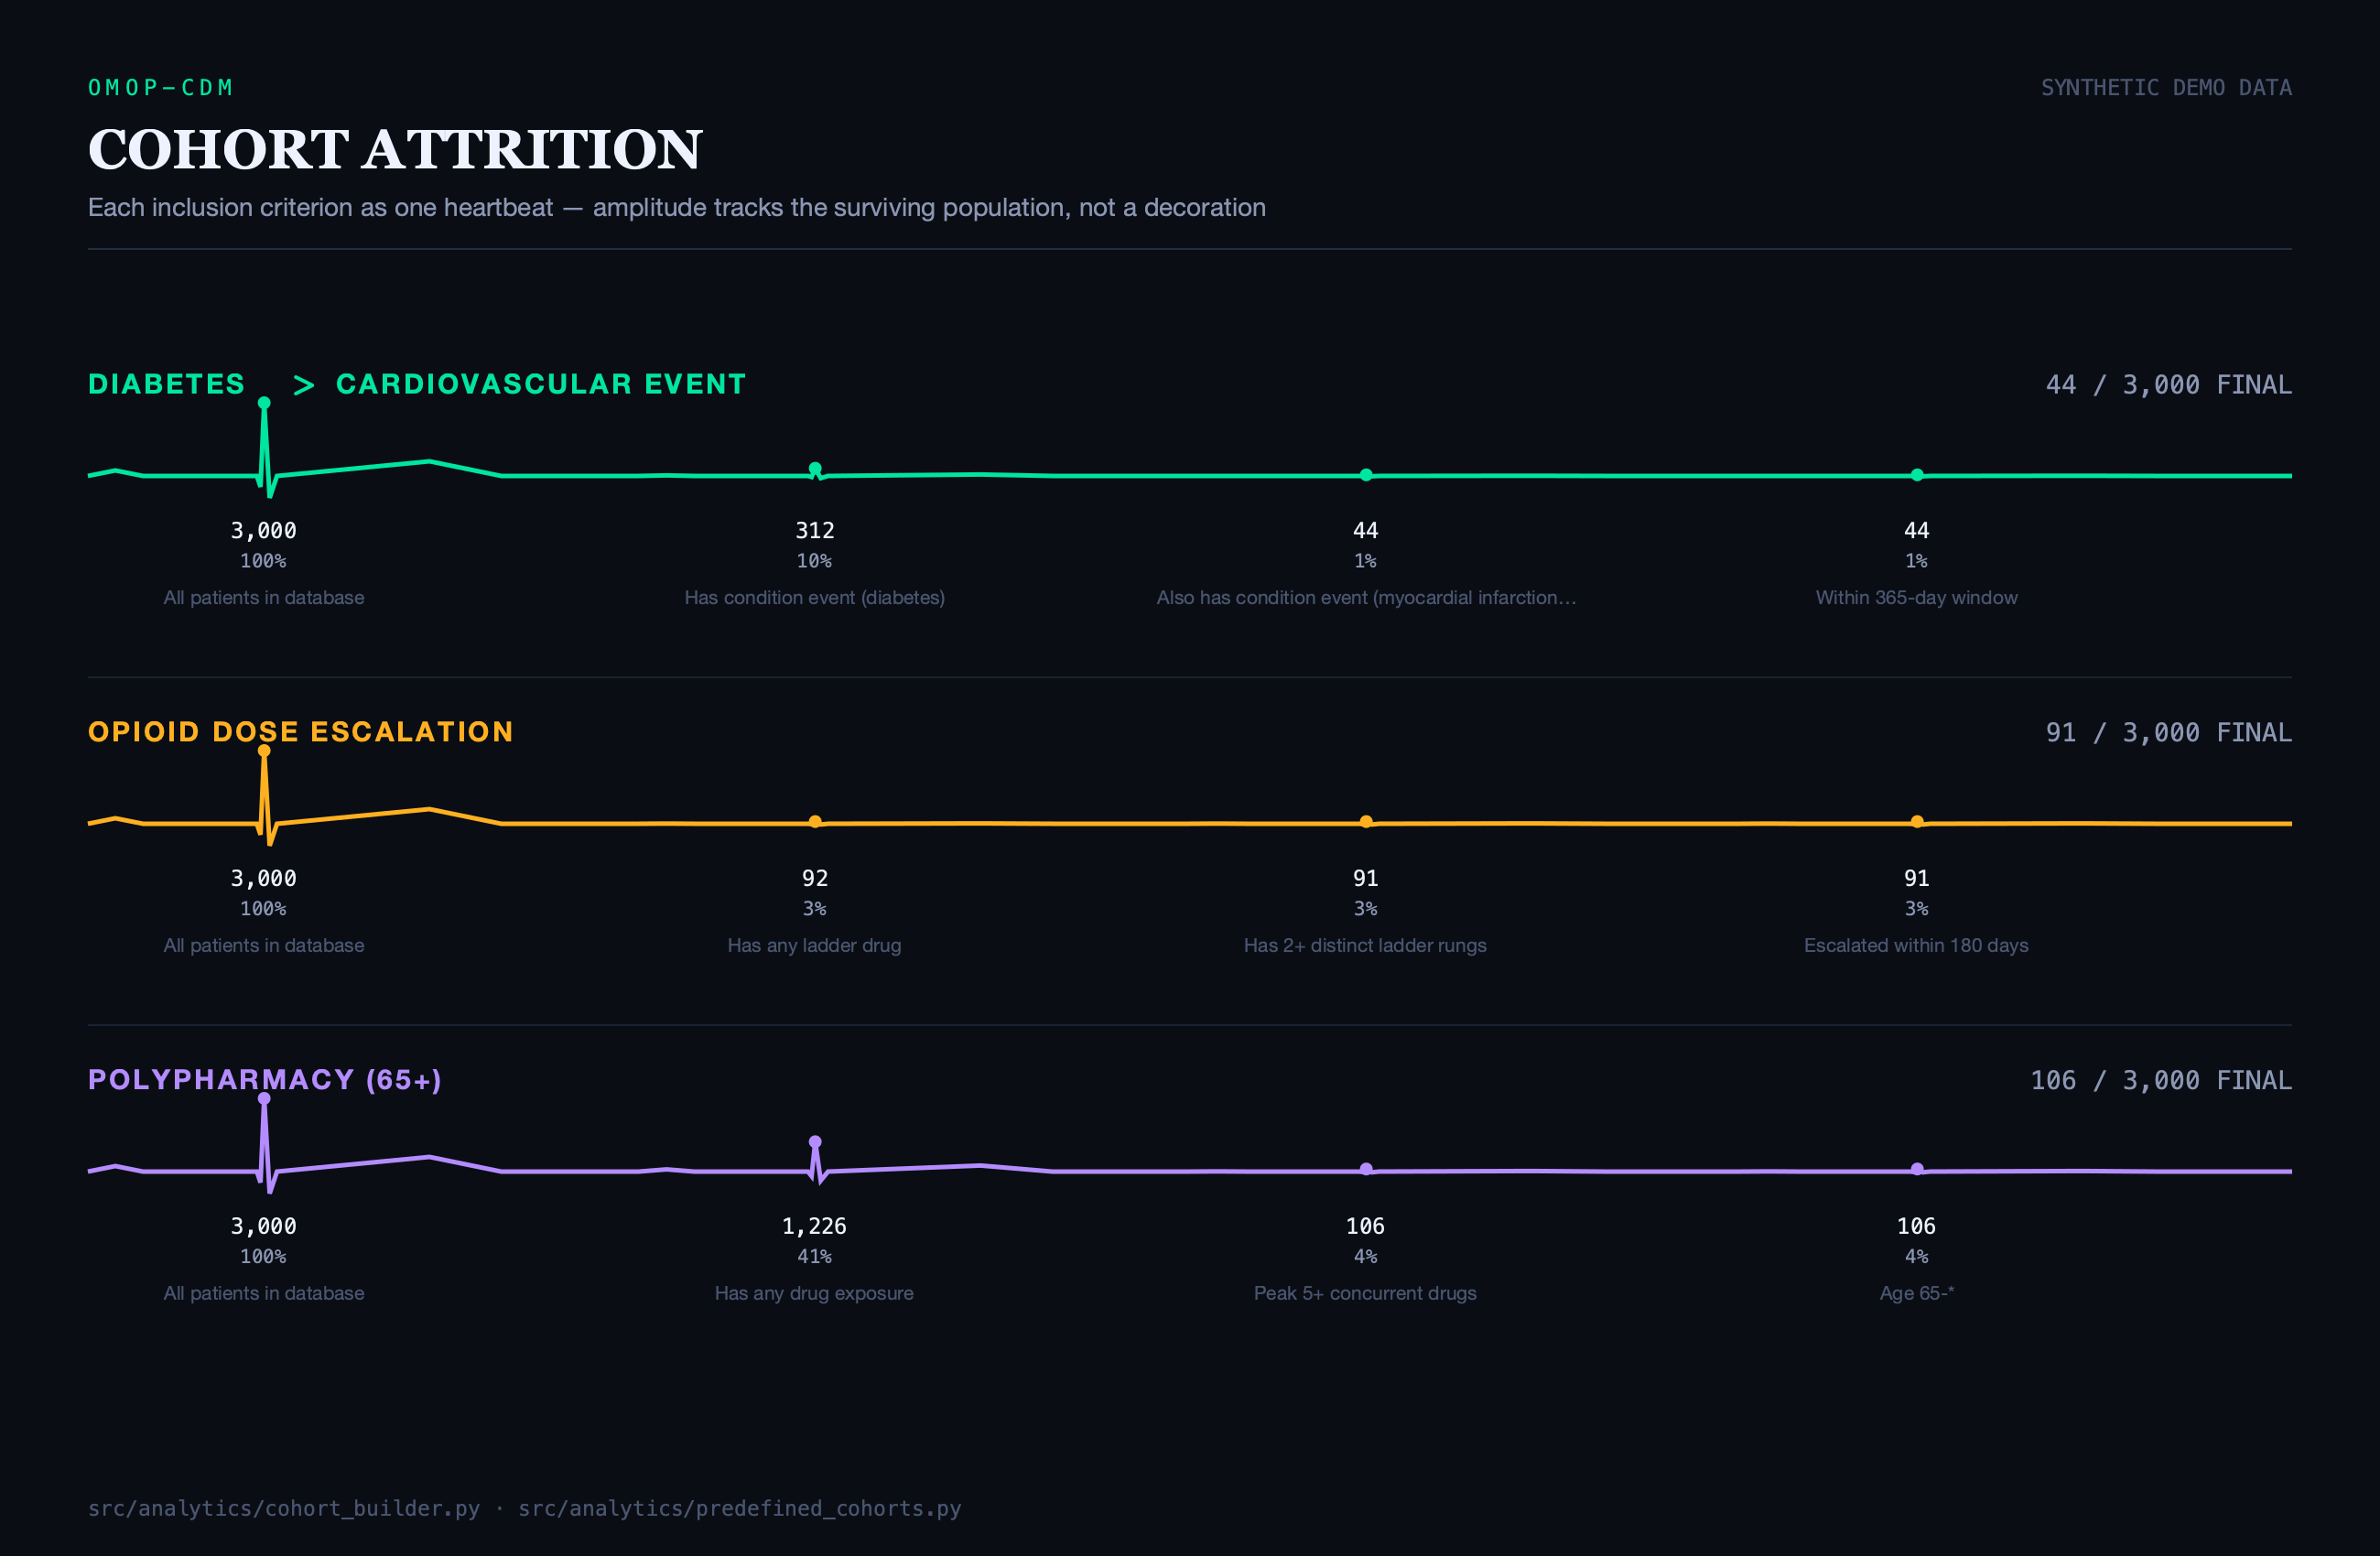

In [2]:
import subprocess
import sys
from IPython.display import Image

subprocess.run([sys.executable, "notebooks/build_cohort_attrition.py"], cwd="..", check=True)
Image(filename="../docs/assets/visualizations/cohort_attrition_waterfalls.png")


## Opioid escalation: what the prescriptions actually look like

Attrition shows how many patients qualify; it doesn't show what qualifying
looks like. For the escalation cohort specifically, that's a sequence of
prescriptions climbing a potency ladder, rendered here as a 14-patient
telemetry strip: each prescription is one spike, and both its height and
color climb with the drug's position on the ladder (codeine's a small cyan
blip, fentanyl's a tall red one), so the escalation itself is visible in the
trace shape, not just labeled beside it. The glowing bar trailing each spike
is how long that prescription actually ran.

Dates are aligned to each patient's own first opioid exposure (day 0) rather
than plotted on the calendar: patients here range decades apart in age, so
their actual escalation episodes fall at unrelated points in history, and a
shared calendar axis would compress every patient's few-month escalation
window into an indistinguishable sliver.


2026-08-27 11:54:58.431 | INFO     | src.analytics.cohort_builder:define:141 -   Index [Condition] ['diabetes'] resolved to 1 concept IDs
2026-08-27 11:54:58.441 | INFO     | src.analytics.cohort_builder:define:146 -   Outcome [Condition] ['myocardial infarction', 'cerebrovascular accident', 'heart failure', 'coronary arteriosclerosis'] resolved to 4 concept IDs
2026-08-27 11:54:58.442 | INFO     | src.analytics.cohort_builder:execute:191 - Executing cohort: diabetes_complications
2026-08-27 11:54:58.471 | INFO     | src.analytics.cohort_builder:execute:240 - Cohort 'diabetes_complications': 44 members
2026-08-27 11:54:58.471 | INFO     | src.analytics.cohort_builder:execute_escalation:285 - Executing escalation cohort: opioid_escalation
2026-08-27 11:54:58.591 | INFO     | src.analytics.cohort_builder:execute_escalation:353 - Cohort 'opioid_escalation': 91 members
2026-08-27 11:54:58.591 | INFO     | src.analytics.cohort_builder:execute_concurrent_drug_count:379 - Executing concurrent

Saved docs/assets/visualizations/opioid_escalation_timeline.svg and opioid_escalation_timeline.png


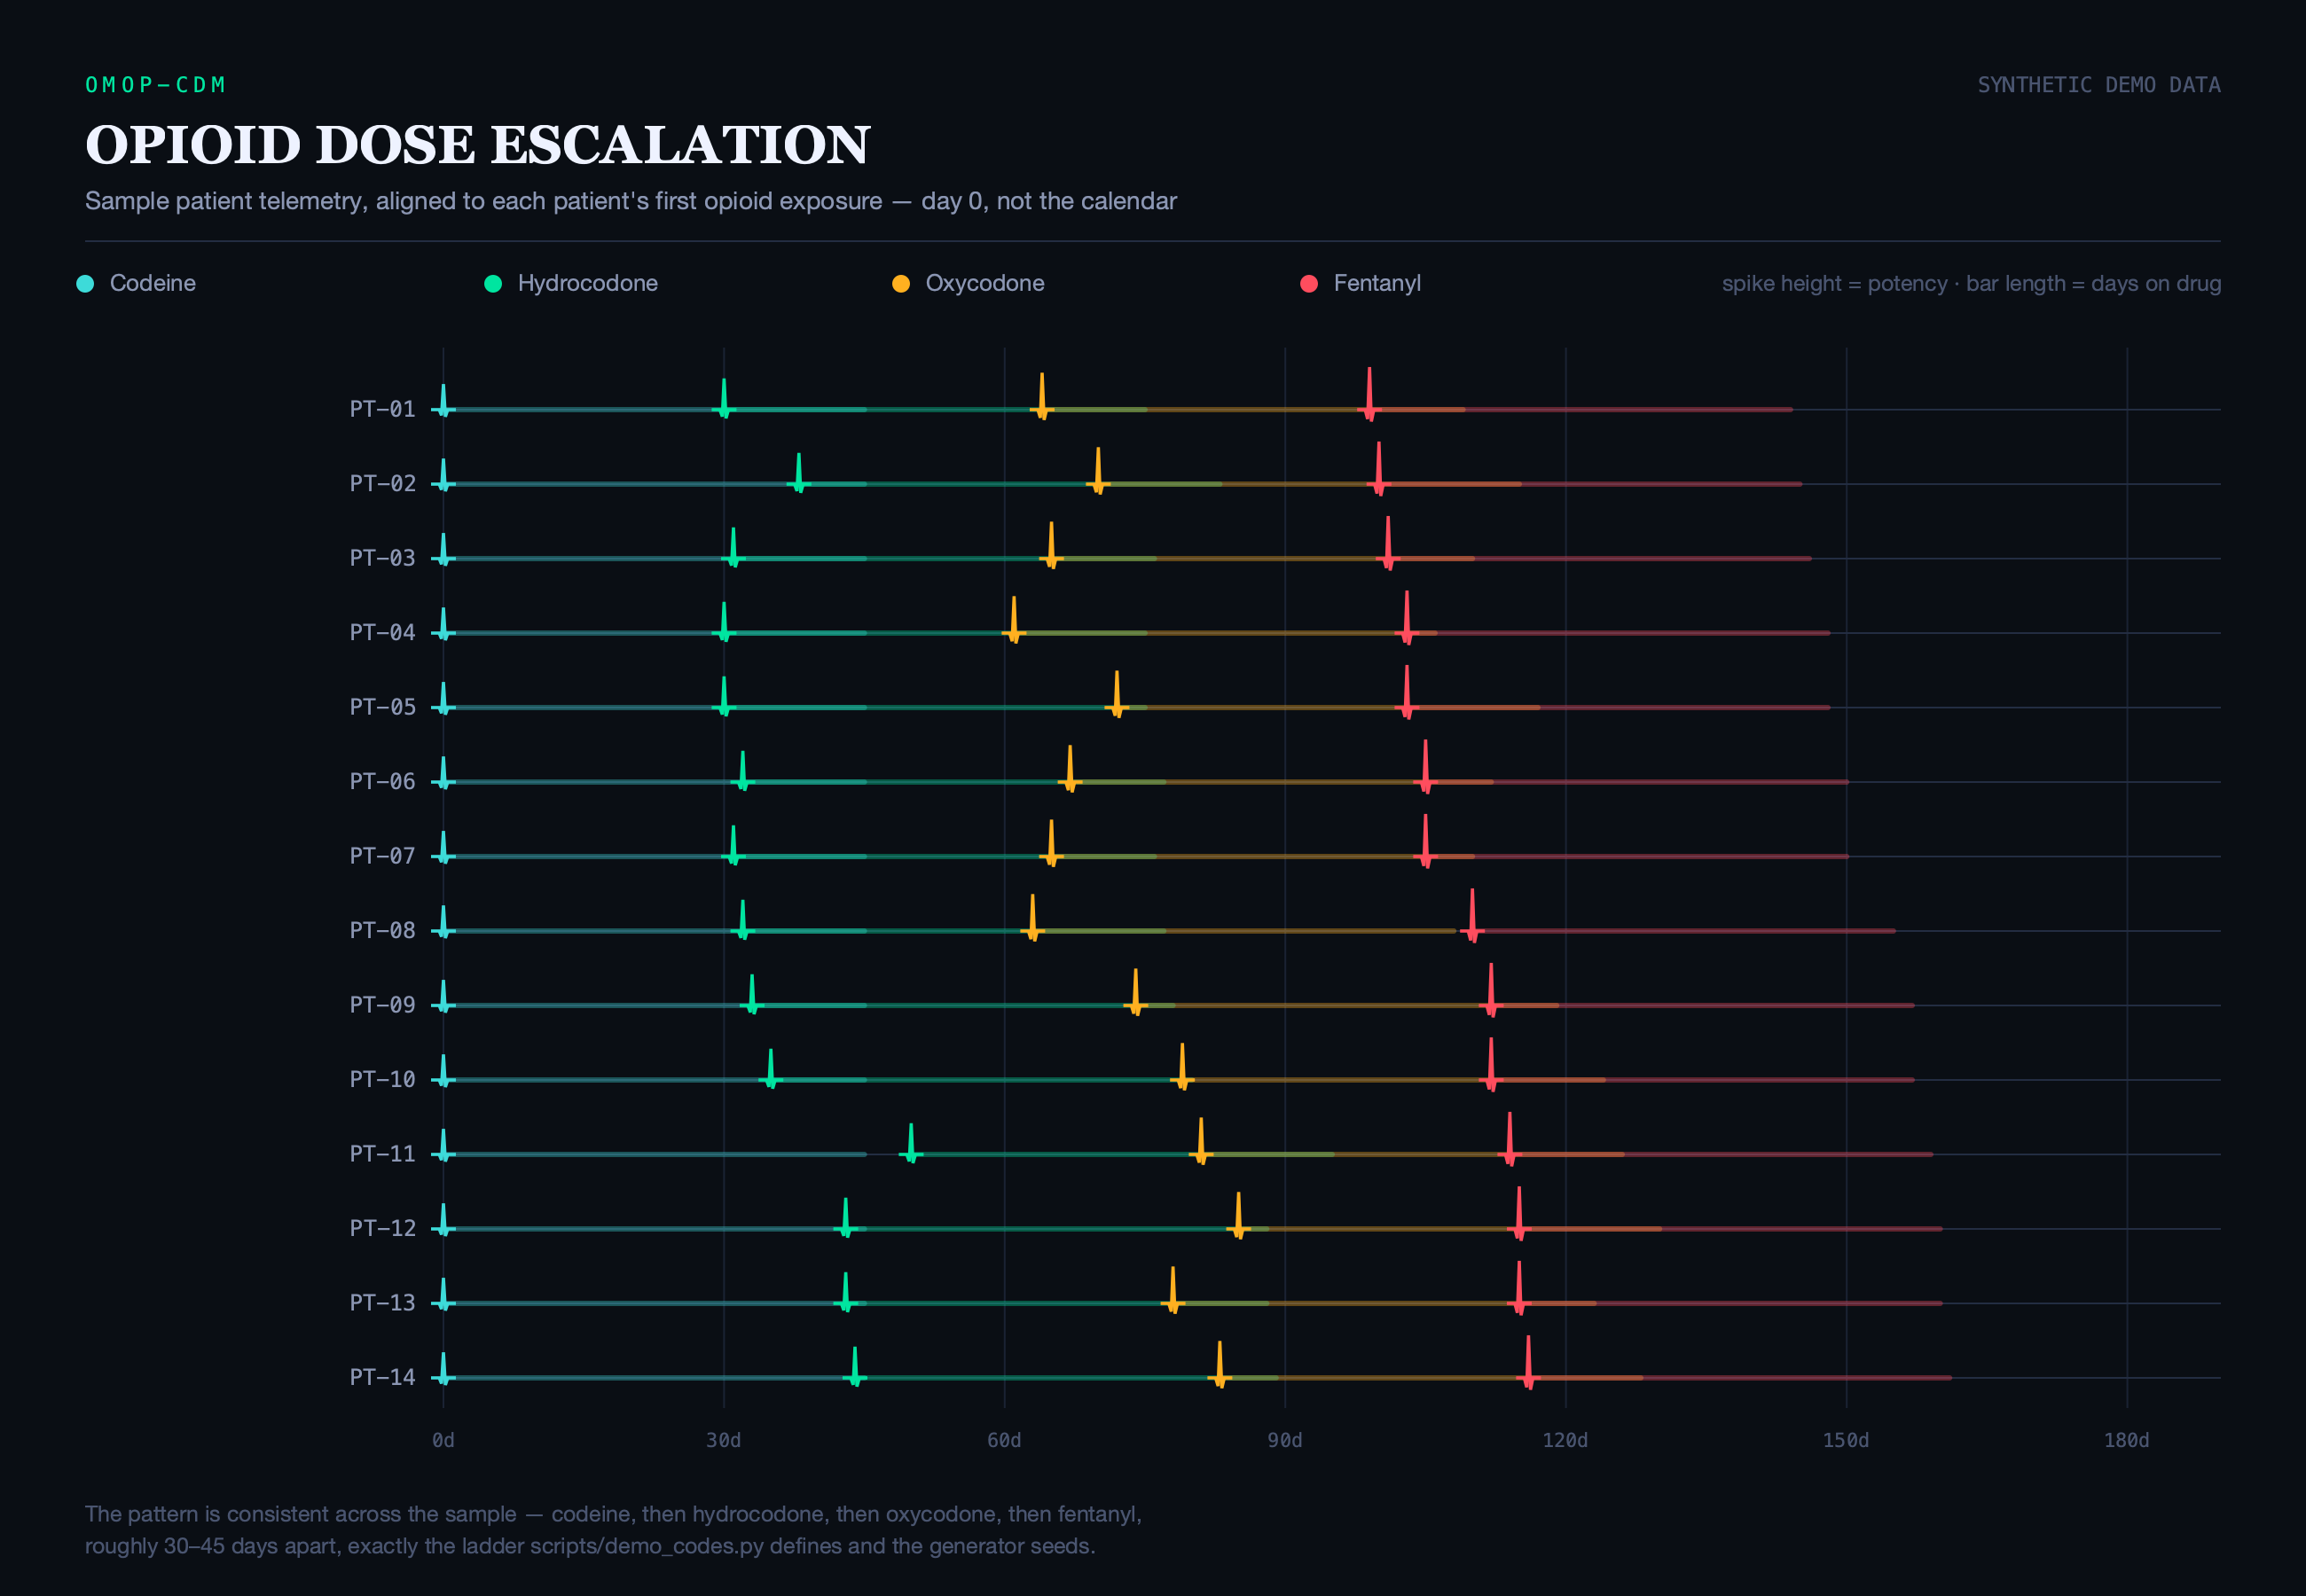

In [3]:
import subprocess
import sys
from IPython.display import Image

subprocess.run([sys.executable, "notebooks/build_opioid_escalation.py"], cwd="..", check=True)
Image(filename="../docs/assets/visualizations/opioid_escalation_timeline.png")


## Reading this

The escalation pattern is consistent across the sample: codeine, then
hydrocodone, then oxycodone, then fentanyl, each roughly 30-45 days apart —
exactly the ladder `scripts/demo_codes.py` defines and the demo data generator
seeds. In a real population this is the chart that turns "91 patients
escalated" into "here's what escalation actually looked like for them,"
which is the question a drug utilization review is actually asking.